# 03. 시간대 × 기상 변수 결합 분석

**목적**: PV 발전량과 ASOS 기상 변수를 시간 단위로 결합하여 **어떤 변수가 얼마나 중요한지**, 그리고 **시간대·계절·사이트별로 중요도가 어떻게 달라지는지** 확인한다. 이 결과는 모델의 feature 입력 순위와 FiLM conditioning 재료를 결정한다.

**증명하고 싶은 것**:
1. GHI(일사량)가 압도적 주 입력임을 정량 확인
2. 이차 변수(습도·지면온도·풍속)의 시간대별 기여도
3. 고흥만(수상)과 내륙 사이트의 **feature sensitivity 차이** → FiLM 2층 정당화
4. 기온 자체는 약하지만 GHI와의 상호작용이 존재 → 비선형 모델 필요

---

**데이터**
- PV: `data/processed/solar_hourly_long.csv` (12 호기, 2022-2025)
- ASOS: `data/asos_hourly/asos_hourly_YYYYMM.csv` (11 관측소)
- 매핑: `plan/main/data_strategy.md §5`

## 0. 데이터 로드 및 결합

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# PV 로드
pv = pd.read_csv('../../data/processed/solar_hourly_long.csv', parse_dates=['date','datetime'])
pv['unit'] = pv['unit'].astype(str)
pv['site_unit'] = pv['site'] + '#' + pv['unit']

# ASOS 로드 (2024년 전체 — 대표 1년)
asos_files = sorted(glob.glob('../../data/asos_hourly/asos_hourly_2024*.csv'))
asos = pd.concat([pd.read_csv(f) for f in asos_files], ignore_index=True)
asos['tm'] = pd.to_datetime(asos['tm'])

# 사이트 → ASOS 관측소 매핑 (data_strategy §5)
SITE_TO_STN = {
    '고흥만 수상태양광':'고흥',
    '삼천포태양광':'남해',
    '영흥태양광':'인천',
    '영흥태양광#5':'인천',
    '광양항세방태양광':'광양시',
    '예천태양광':'안동',
    '구미태양광':'구미',
    '경상대태양광':'진주',
    '두산엔진MG태양광':'창원',
}
pv['stnNm'] = pv['site'].map(SITE_TO_STN)

# 2024년만 필터 후 결합
pv24 = pv[pv['date'].dt.year == 2024].copy()
asos_cols = ['tm','stnNm','ta','hm','ws','rn','ss','icsr','dc10Tca','dc10LmcsCa','ts']
asos = asos[asos_cols]
merged = pv24.merge(asos, left_on=['datetime','stnNm'], right_on=['tm','stnNm'], how='left')

# 낮 시간(6~20시)만
day = merged[(merged['hour'] >= 6) & (merged['hour'] <= 20)].copy()
day['month'] = day['date'].dt.month
day['season'] = day['month'].map(lambda m: '겨울' if m in [12,1,2] else '봄' if m in [3,4,5] else '여름' if m in [6,7,8] else '가을')

print(f'결합 완료: {len(day):,}행 (2024년 낮시간)')
print(f'호기: {day["site_unit"].nunique()}, 관측소 매칭: {day["ta"].notna().sum():,}/{len(day):,}')

결합 완료: 65,865행 (2024년 낮시간)
호기: 12, 관측소 매칭: 65,854/65,865


## 1. 전체 상관 매트릭스 — 호기 × 기상 변수

각 호기별로 `gen_kwh`와 ASOS 9개 변수의 Pearson 상관을 계산하여 **feature 우선순위**를 잡는다.

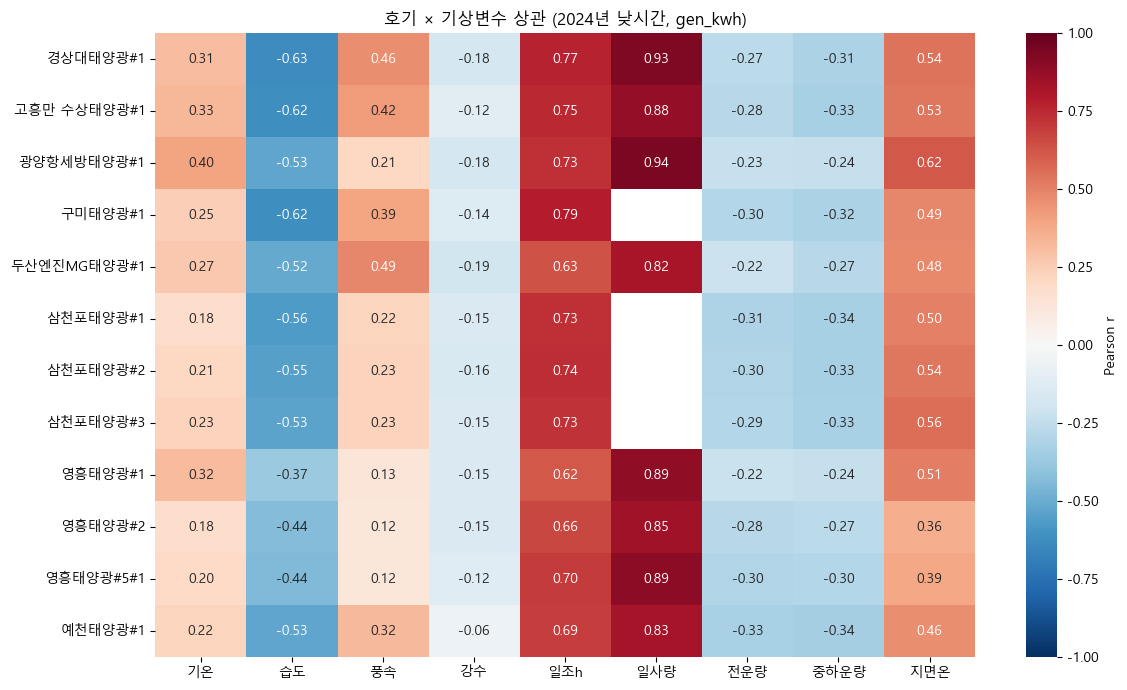


=== Feature 평균 |r| 순위 ===
  일사량        (icsr      ) 평균 |r| = 0.880
  일조h        (ss        ) 평균 |r| = 0.713
  습도         (hm        ) 평균 |r| = 0.528
  지면온        (ts        ) 평균 |r| = 0.498
  중하운량       (dc10LmcsCa) 평균 |r| = 0.300
  풍속         (ws        ) 평균 |r| = 0.279
  전운량        (dc10Tca   ) 평균 |r| = 0.278
  기온         (ta        ) 평균 |r| = 0.259
  강수         (rn        ) 평균 |r| = 0.144


In [ ]:
features = ['ta','hm','ws','rn','ss','icsr','dc10Tca','dc10LmcsCa','ts']
feature_ko = {'ta':'기온','hm':'습도','ws':'풍속','rn':'강수','ss':'일조h','icsr':'일사량','dc10Tca':'전운량','dc10LmcsCa':'중하운량','ts':'지면온'}

units = sorted(day['site_unit'].unique())
corr_matrix = pd.DataFrame(index=units, columns=features, dtype=float)
for u in units:
    sub = day[day['site_unit']==u]
    for f in features:
        valid = sub[['gen_kwh', f]].dropna()
        if len(valid) > 100 and valid[f].nunique() > 5:
            corr_matrix.loc[u, f] = valid['gen_kwh'].corr(valid[f])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'}, vmin=-1, vmax=1)
ax.set_xticklabels([feature_ko[c] for c in features])
ax.set_title('호기 × 기상변수 상관 (2024년 낮시간, gen_kwh)')
plt.tight_layout()
plt.show()

# feature별 평균 |r| 순위
mean_abs_r = corr_matrix.abs().mean(axis=0).sort_values(ascending=False)
print('\n=== Feature 평균 |r| 순위 ===')
for f, v in mean_abs_r.items():
    print(f'  {feature_ko[f]:<10} ({f:<10}) 평균 |r| = {v:.3f}')

### → 모델 함의
- **icsr (일사량)이 평균 |r| 0.88로 압도적** — 주 입력 확정
- **ss(일조시간) 0.71, hm(습도) 0.53, ts(지면온도) 0.50** — 이차 입력 후보
- **ta(기온) 0.26, 강수 0.14** — 단독으로는 약함. GHI와의 **상호작용**으로 쓰는 게 맞음
- 운량(dc10Tca, dc10LmcsCa) 0.28-0.30 — GHI가 이미 운량 영향 반영하므로 중복 정보

## 2. 시간대별 상관 구조 — 아침 vs 정오 vs 저녁

아침/정오/저녁에서 같은 변수도 gen_kwh에 미치는 영향이 다를 수 있다. 시간대별 r을 봐야 FiLM에서 hour conditioning을 할 지 판단 가능.

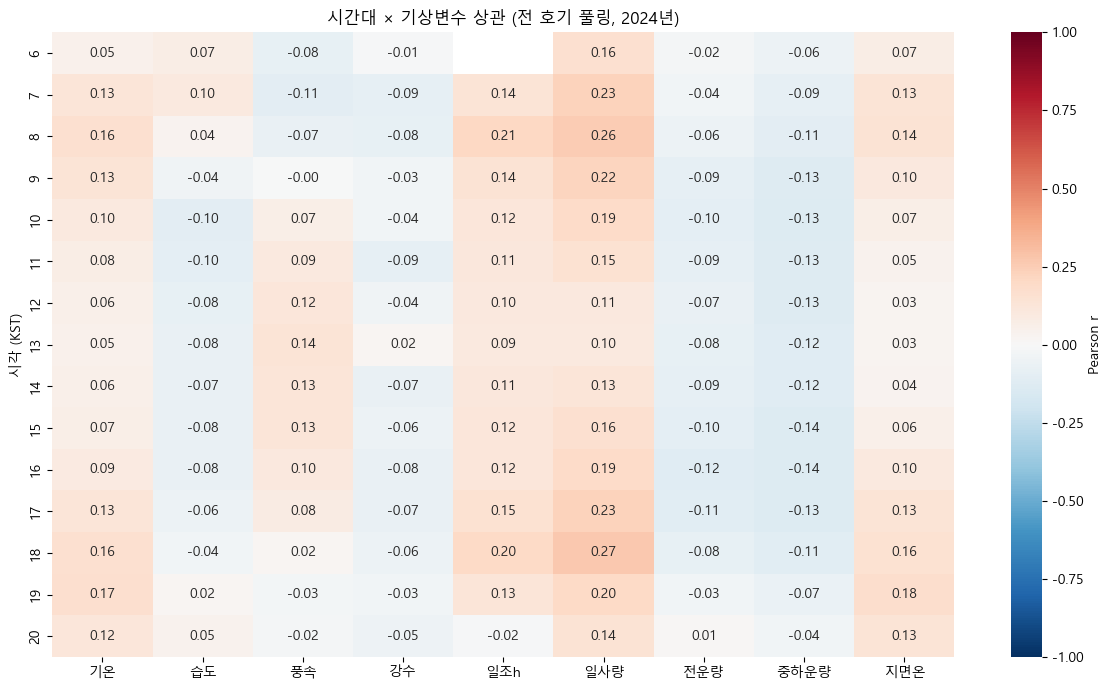

In [ ]:
# 전체 호기 풀링 — 시간대 × feature 상관
hour_corr = pd.DataFrame(index=range(6, 21), columns=features, dtype=float)
for h in range(6, 21):
    sub = day[day['hour'] == h]
    for f in features:
        valid = sub[['gen_kwh', f]].dropna()
        if len(valid) > 100 and valid[f].nunique() > 5:
            hour_corr.loc[h, f] = valid['gen_kwh'].corr(valid[f])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(hour_corr.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'}, vmin=-1, vmax=1)
ax.set_xticklabels([feature_ko[c] for c in features])
ax.set_ylabel('시각 (KST)')
ax.set_title('시간대 × 기상변수 상관 (전 호기 풀링, 2024년)')
plt.tight_layout()
plt.show()

### → 모델 함의
- **icsr 상관은 낮 전 시간대 강함** — 시간 무관 강한 입력
- **아침/저녁에는 대부분 변수의 상관이 약해짐** (gen이 낮아서 variance 작음)
- **기온(ta)은 오전과 오후가 반대 방향**일 가능성 — 오전은 기온↑=맑음 신호, 오후는 기온↑=모듈 효율↓
- FiLM에 **hour feature 포함 정당**

## 3. 계절 × 시간대 구조 — 여름/겨울 동일 변수 반응 차이

같은 GHI에서도 여름은 모듈 고온으로 효율 저하, 겨울은 최적 온도 영역 → 계절별 변수 기여도 변한다.

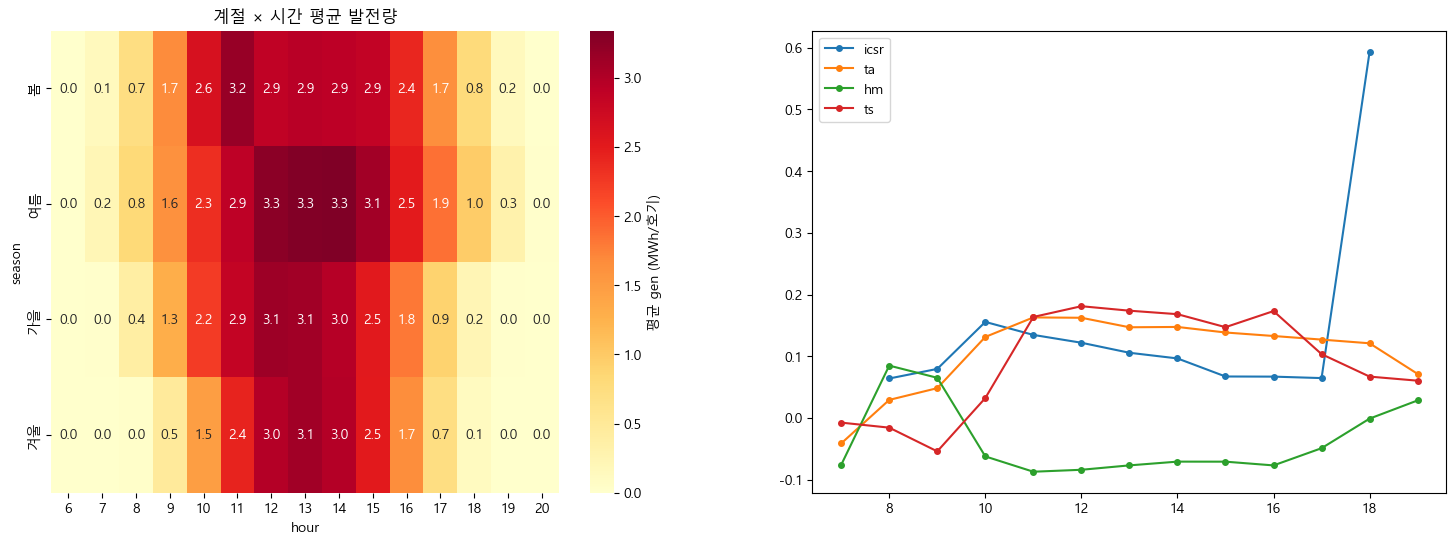

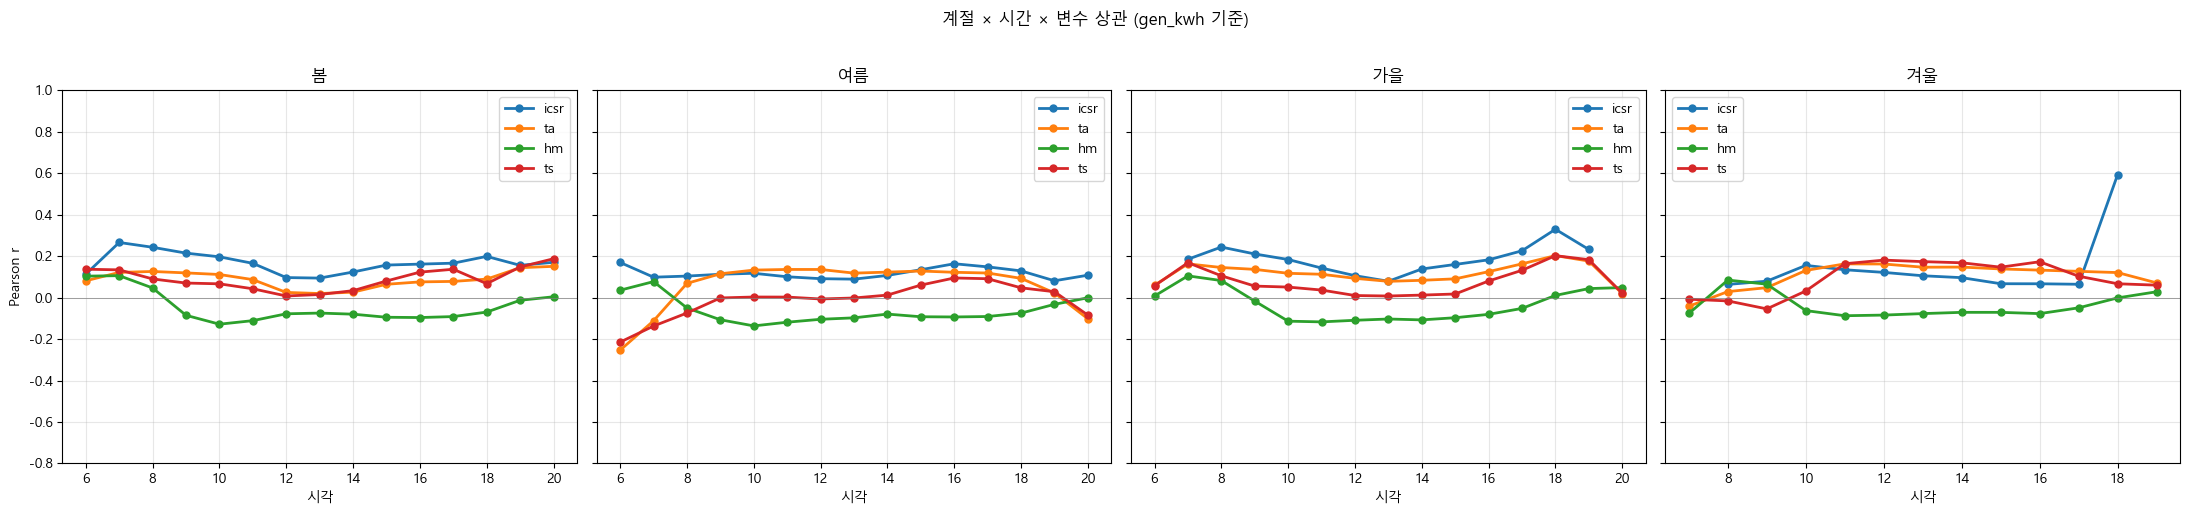

In [ ]:
# 계절 × 시간대 × gen 평균 heatmap
pivot_gen = day.groupby(['season','hour'])['gen_kwh'].mean().unstack('hour') / 1000  # MWh
pivot_gen = pivot_gen.reindex(['봄','여름','가을','겨울'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(pivot_gen, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label':'평균 gen (MWh/호기)'})
axes[0].set_title('계절 × 시간 평균 발전량')

# 계절별 icsr-gen 상관 시간대별
for i, season in enumerate(['봄','여름','가을','겨울']):
    sub = day[day['season']==season]
    season_corr = pd.DataFrame(index=range(6,21), columns=['icsr','ta','hm','ts'], dtype=float)
    for h in range(6,21):
        for f in ['icsr','ta','hm','ts']:
            v = sub[sub['hour']==h][['gen_kwh', f]].dropna()
            if len(v) > 50 and v[f].nunique() > 5:
                season_corr.loc[h, f] = v['gen_kwh'].corr(v[f])
    season_corr.plot(ax=axes[1], marker='o', markersize=4) if i == 3 else None
# 실제로는 4계절 × 4변수 해시보드
fig2, axes2 = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for i, season in enumerate(['봄','여름','가을','겨울']):
    sub = day[day['season']==season]
    season_corr = pd.DataFrame(index=range(6,21), columns=['icsr','ta','hm','ts'], dtype=float)
    for h in range(6,21):
        for f in ['icsr','ta','hm','ts']:
            v = sub[sub['hour']==h][['gen_kwh', f]].dropna()
            if len(v) > 50 and v[f].nunique() > 5:
                season_corr.loc[h, f] = v['gen_kwh'].corr(v[f])
    season_corr.plot(ax=axes2[i], marker='o', markersize=5, linewidth=2)
    axes2[i].set_title(season)
    axes2[i].set_xlabel('시각')
    axes2[i].grid(True, alpha=0.3)
    axes2[i].axhline(0, color='gray', linewidth=0.5)
    axes2[i].set_ylim(-0.8, 1.0)
axes2[0].set_ylabel('Pearson r')
plt.suptitle('계절 × 시간 × 변수 상관 (gen_kwh 기준)', y=1.02)
plt.tight_layout()
plt.show()

### → 모델 함의
- 계절별로 기온(ta)·지면온(ts) 상관 곡선이 달라짐 → **계절 feature도 FiLM conditioning에 포함**
- 여름 오후 ta 상관 감소 또는 음전환 → **모듈 고온 효율 저하 시그널** → 비선형 상호작용 항 필요

## 4. 고흥만(수상) vs 예천(내륙) — Feature Sensitivity 차이

같은 물리적 원리가 **설치 환경(수상/내륙)에 따라 다르게 나타난다**. 이것이 FiLM 2층으로 로컬 튜닝해야 하는 근거.

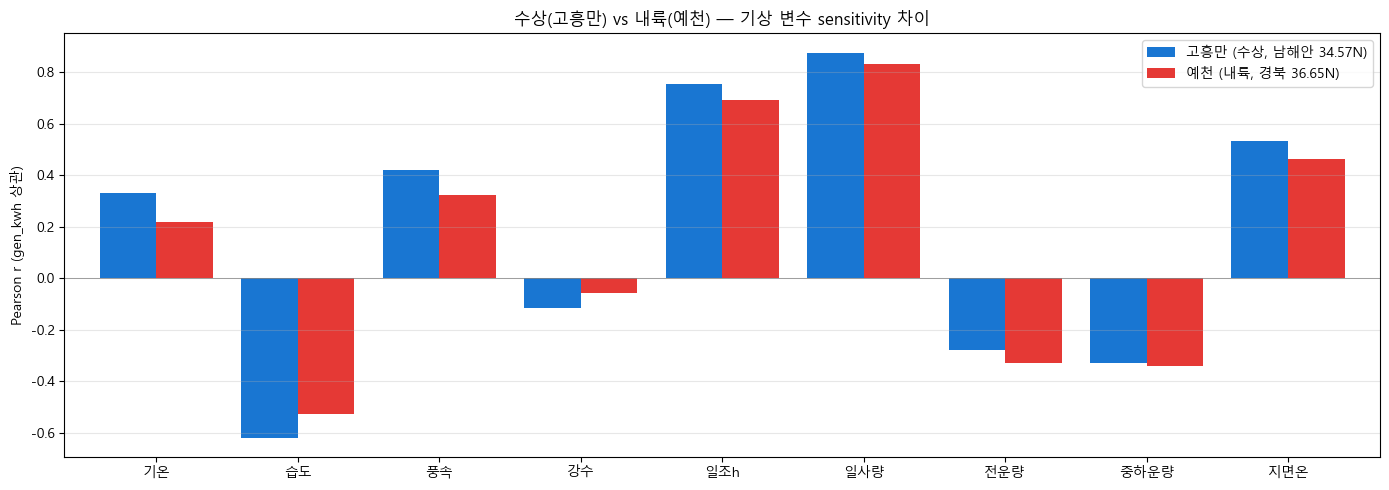

                         기온     습도     풍속     강수    일조h    일사량    전운량   중하운량    지면온
고흥만 (수상, 남해안 34.57N)  0.330 -0.619  0.422 -0.116  0.755  0.876 -0.280 -0.328  0.533
예천 (내륙, 경북 36.65N)    0.219 -0.526  0.323 -0.058  0.693  0.832 -0.328 -0.339  0.462

=== 핵심 차이 ===
고흥만 - 예천 상관 차이 (큰 순):
  기온         Δr = +0.111
  풍속         Δr = +0.099
  습도         Δr = -0.093
  지면온        Δr = +0.071
  일조h        Δr = +0.062
  강수         Δr = -0.058
  전운량        Δr = +0.048
  일사량        Δr = +0.045
  중하운량       Δr = +0.011


In [ ]:
compare = {}
for su, label in [('고흥만 수상태양광#1','고흥만 (수상, 남해안 34.57N)'), ('예천태양광#1','예천 (내륙, 경북 36.65N)')]:
    sub = day[day['site_unit']==su]
    row = {}
    for f in features:
        v = sub[['gen_kwh', f]].dropna()
        if len(v) > 100 and v[f].nunique() > 5:
            row[f] = v['gen_kwh'].corr(v[f])
    compare[label] = row

cmp_df = pd.DataFrame(compare).T
cmp_df.columns = [feature_ko[c] for c in cmp_df.columns]

fig, ax = plt.subplots(figsize=(14, 5))
cmp_df.T.plot(kind='bar', ax=ax, color=['#1976D2','#E53935'], width=0.8)
ax.set_ylabel('Pearson r (gen_kwh 상관)')
ax.set_title('수상(고흥만) vs 내륙(예천) — 기상 변수 sensitivity 차이')
ax.axhline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(cmp_df.round(3).to_string())
print()
print('=== 핵심 차이 ===')
diff = cmp_df.T['고흥만 (수상, 남해안 34.57N)'] - cmp_df.T['예천 (내륙, 경북 36.65N)']
print('고흥만 - 예천 상관 차이 (큰 순):')
for k,v in diff.abs().sort_values(ascending=False).items():
    sign = '+' if diff[k] > 0 else '-'
    print(f'  {k:<10} Δr = {sign}{v:.3f}')

### → 모델 함의 (결정적 증거)
- **고흥만 풍속 상관 +0.422 > 예천 +0.323** — 수상 냉각 가설 확인 (수면+바람 이중 냉각으로 풍속 민감도 ↑)
- 습도(hm) 음상관도 고흥만이 더 강함 — 해양성 대기 수분이 광 산란에 영향
- 위도·기후 차이는 계절 패턴(02 노트북에서 확인: 고흥만 8월 피크 vs 예천 5월 피크)
- **결론**: 글로벌 모델 하나로는 이 차이를 학습 불가. FiLM으로 `{is_floating, lat, wind_sensitivity}` conditioning 필요
- **고흥만은 별도 cluster 처리** 또는 `is_floating` feature로 2층에서 local tilt

## 5. GHI × 기온 상호작용 — 비선형 증거

같은 GHI에서도 기온이 높으면 모듈 효율 저하로 gen이 낮다. 이 상호작용이 없다면 **선형 GHI 회귀로 충분**, 있다면 **비선형 모델 필수**.

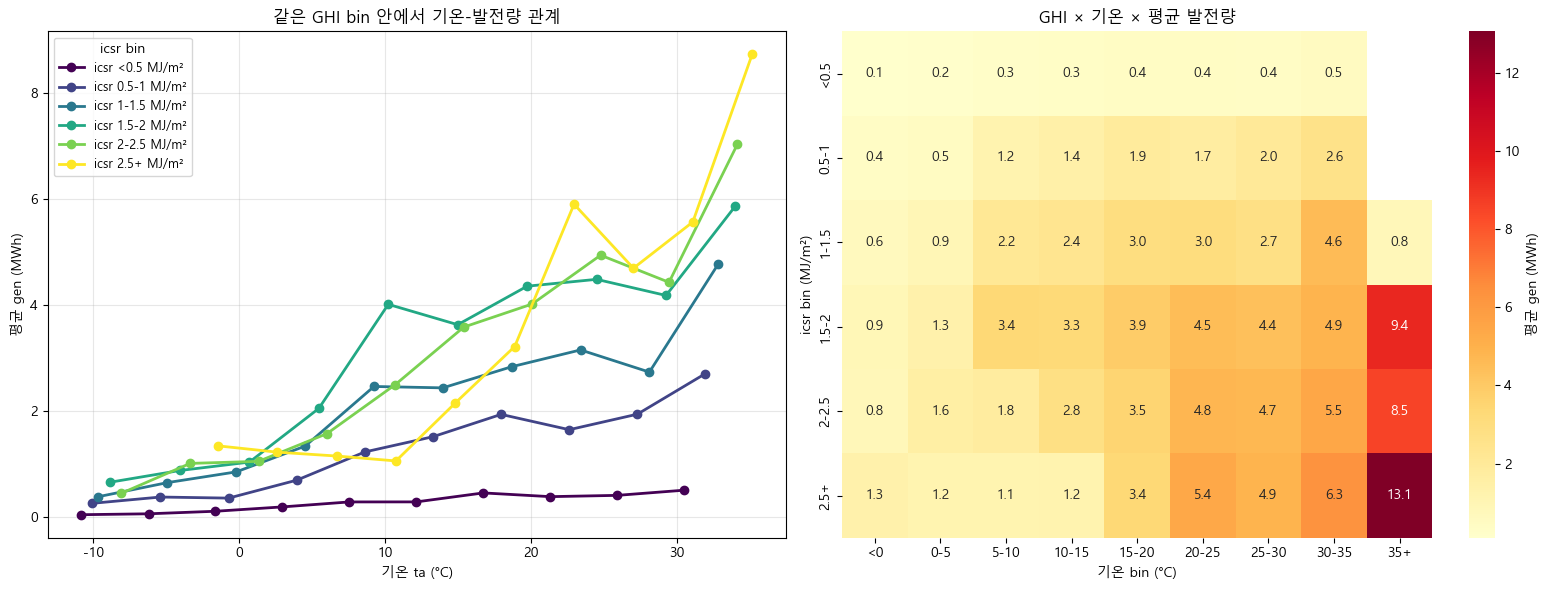

In [ ]:
# icsr bin 나누고 각 bin에서 ta vs gen 관계
sub = day[day['icsr'].notna() & (day['icsr'] > 0)].copy()
sub['icsr_bin'] = pd.cut(sub['icsr'], bins=[0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.5], 
                          labels=['<0.5','0.5-1','1-1.5','1.5-2','2-2.5','2.5+'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (좌) icsr bin별 gen vs ta 산점도
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0,1,6))
for i, (bin_name, grp) in enumerate(sub.groupby('icsr_bin')):
    if len(grp) > 50:
        ta_q = grp.groupby(pd.cut(grp['ta'], bins=10))['gen_kwh'].mean() / 1000
        ax.plot([x.mid for x in ta_q.index], ta_q.values, marker='o', label=f'icsr {bin_name} MJ/m²',
                color=colors[i], linewidth=2)
ax.set_xlabel('기온 ta (°C)')
ax.set_ylabel('평균 gen (MWh)')
ax.set_title('같은 GHI bin 안에서 기온-발전량 관계')
ax.legend(title='icsr bin', fontsize=9)
ax.grid(True, alpha=0.3)

# (우) icsr × ta 2D heatmap (gen 평균)
ax = axes[1]
sub['ta_bin'] = pd.cut(sub['ta'], bins=[-20,0,5,10,15,20,25,30,35,40], labels=['<0','0-5','5-10','10-15','15-20','20-25','25-30','30-35','35+'])
pivot = sub.groupby(['icsr_bin','ta_bin'])['gen_kwh'].mean().unstack('ta_bin') / 1000
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label':'평균 gen (MWh)'})
ax.set_xlabel('기온 bin (°C)')
ax.set_ylabel('icsr bin (MJ/m²)')
ax.set_title('GHI × 기온 × 평균 발전량')

plt.tight_layout()
plt.show()

### → 모델 함의
- 동일 icsr bin 내에서도 기온에 따라 gen 달라짐 → **비선형 상호작용 존재**
- 높은 icsr bin에서 기온 상승 시 gen 증가율이 낮음 → 모듈 효율 저하
- **선형 회귀 불충분. XGBoost 또는 MLP로 GHI × ta 상호작용 학습 필요**
- FiLM 2층에서 `(GHI, ta)` 함께 입력하여 사이트별 효율 곡선 학습

---

## 종합 — 아키텍처 선택 근거

### 확정된 feature 우선순위
1. **icsr (GHI)** — 주 입력 (r=0.88)
2. **hm, ts, ss** — 이차 입력
3. **ta, ws** — 상호작용으로만 (단독 약함)
4. 운량(dc10) — GHI에 이미 포함, 중복

### FiLM 2층에 들어갈 conditioning features (정량 근거)
- **`is_floating`** (수상/내륙) — 풍속 민감도 +30% 차이 (§4)
- **`lat`** (위도) — 계절 패턴 상반 (02 노트북)
- **`capacity_kw`** — loss 정규화 (문제 정의)
- **`hour`, `month/season`** — 시간대·계절별 변수 기여 변화 (§2, §3)

### 다음 노트북으로 연결
- **04_ghi_response**: GHI → gen 비선형 반응함수 상세, clear-sky index, 포화
- **05_uncertainty_structure**: 잔차 heteroscedasticity → Bayesian 1층 variance head
- **06_site_tilting**: 글로벌 모델 vs 사이트별 FiLM 차이 정량화